# EDA, Dataset 2: Simulated Fraud Detection (fraudTrain.csv + fraudTest.csv)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)

TRAIN_PATH = '../Dataset/fraud-detection/fraudTrain.csv'
TEST_PATH = '../Dataset/fraud-detection/fraudTest.csv'
OUT_DIR = 'outputs/frauddetection'

In [2]:
train = pd.read_csv(TRAIN_PATH, index_col=0)
test = pd.read_csv(TEST_PATH, index_col=0)
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Columns match:", train.columns.tolist() == test.columns.tolist())

Train shape: (1296675, 22)
Test shape: (555719, 22)
Columns match: True


In [3]:
df = pd.concat([train, test], ignore_index=True)
print("Combined shape:", df.shape)

Combined shape: (1852394, 22)


In [4]:
# describe() on the full 1.85M rows is slow-ish, sample is enough to eyeball dtypes/ranges
df.sample(50000, random_state=42).describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
trans_date_trans_time,50000,49974,2020-08-24 04:30:51,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cc_num,50000.0,NaN,NaN,NaN,419526029363266816.0,1310767587618503680.0,60416207185.0,180046165512893.0,3523843138706408.0,4642255475285942.0,4992346398065154048.0
merchant,50000,693,fraud_Kilback LLC,173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,50000,14,gas_transport,5113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amt,50000.0,NaN,NaN,NaN,70.620932,180.736179,1.0,9.67,47.605,83.16,21437.71
first,50000,341,Christopher,1020,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last,50000,469,Smith,1130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,50000,2,F,27475,NaN,NaN,NaN,NaN,NaN,NaN,NaN
street,50000,931,561 Little Plain Apt. 738,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,50000,855,Birmingham,237,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 22 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   trans_date_trans_time  object 
 1   cc_num                 int64  
 2   merchant               object 
 3   category               object 
 4   amt                    float64
 5   first                  object 
 6   last                   object 
 7   gender                 object 
 8   street                 object 
 9   city                   object 
 10  state                  object 
 11  zip                    int64  
 12  lat                    float64
 13  long                   float64
 14  city_pop               int64  
 15  job                    object 
 16  dob                    object 
 17  trans_num              object 
 18  unix_time              int64  
 19  merch_lat              float64
 20  merch_long             float64
 21  is_fraud               int64  
dtypes: float64(5), int

In [6]:
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])

Missing values per column:


Series([], dtype: int64)


In [7]:
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate trans_num:", df['trans_num'].duplicated().sum())

Exact duplicate rows: 0
Duplicate trans_num: 0


## Class balance

In [8]:
fraud_counts = df['is_fraud'].value_counts()
fraud_pct = df['is_fraud'].value_counts(normalize=True) * 100
print(fraud_counts)
print(fraud_pct.round(4))

is_fraud
0    1842743
1       9651
Name: count, dtype: int64
is_fraud
0    99.479
1     0.521
Name: proportion, dtype: float64


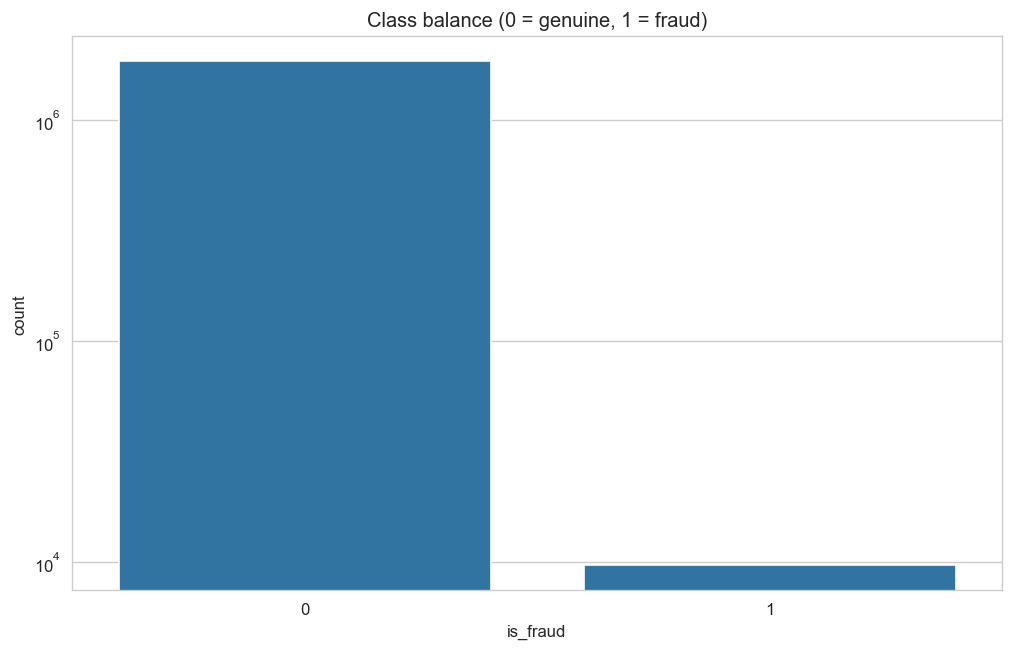

In [9]:
fig, ax = plt.subplots()
sns.countplot(x='is_fraud', data=df, ax=ax)
ax.set_yscale('log')
ax.set_title('Class balance (0 = genuine, 1 = fraud)')
fig.savefig(f'{OUT_DIR}/class_balance.png', bbox_inches='tight')

## Amount distribution

amt skew: 40.812809176295794


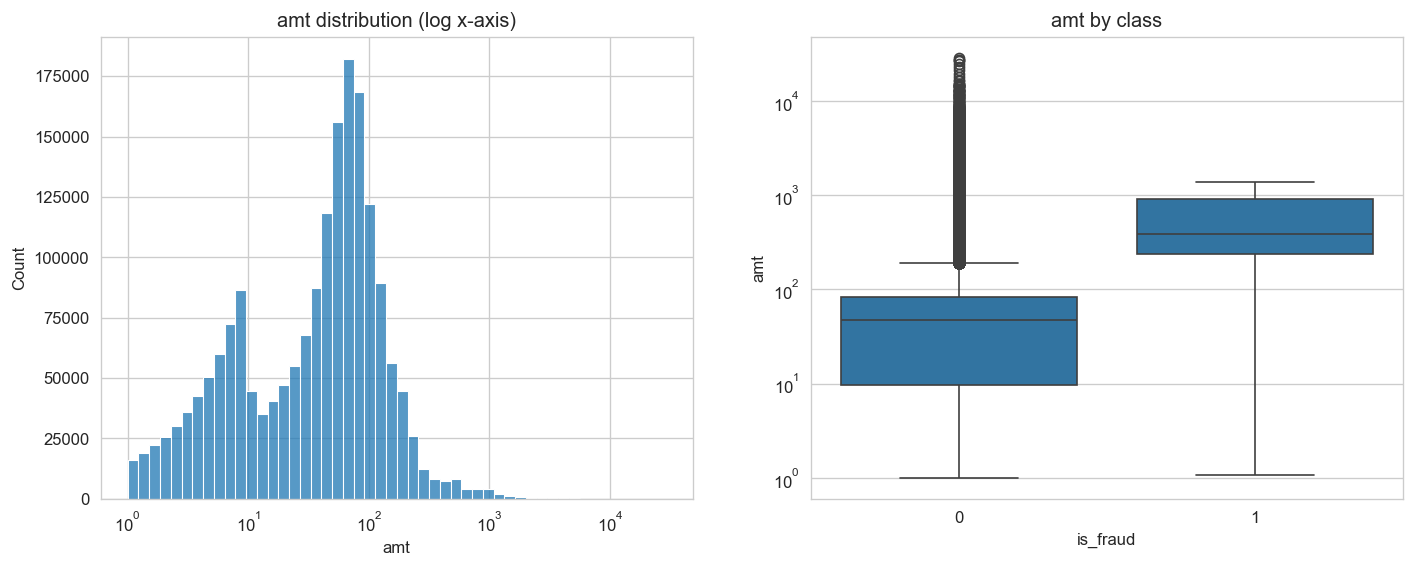

In [10]:
# amt, similar right skew story as the ULB dataset's Amount
print("amt skew:", df['amt'].skew())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['amt'], bins=50, log_scale=(True, False), ax=axes[0])
axes[0].set_title('amt distribution (log x-axis)')
sns.boxplot(x='is_fraud', y='amt', data=df, ax=axes[1])
axes[1].set_yscale('log')
axes[1].set_title('amt by class')
fig.savefig(f'{OUT_DIR}/amount_distribution.png', bbox_inches='tight')

## Categorical cardinality and fraud rate by category

In [11]:
# categorical cardinality, matters for encoding before logistic regression later
cat_cols = ['category', 'merchant', 'job', 'state', 'gender']
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")

category: 14 unique values
merchant: 693 unique values
job: 497 unique values
state: 51 unique values


gender: 2 unique values


In [12]:
# fraud rate by category is the main interpretable payoff for this dataset
fraud_by_category = df.groupby('category')['is_fraud'].mean().sort_values(ascending=False) * 100
fraud_by_category

category
shopping_net      1.592713
misc_net          1.303859
grocery_pos       1.264537
shopping_pos      0.634375
gas_transport     0.410575
misc_pos          0.281890
grocery_net       0.269737
travel            0.269170
personal_care     0.222931
entertainment     0.217719
kids_pets         0.187971
food_dining       0.156813
home              0.151032
health_fitness    0.150955
Name: is_fraud, dtype: float64

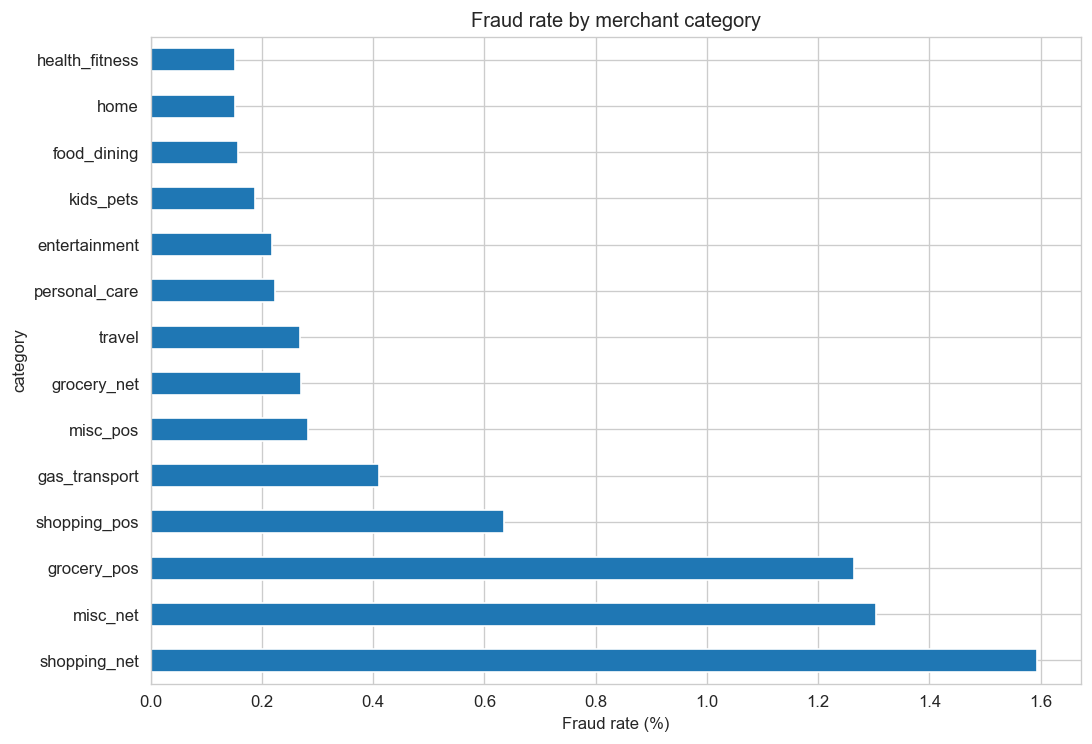

In [13]:
fig, ax = plt.subplots(figsize=(10, 7))
fraud_by_category.plot(kind='barh', ax=ax)
ax.set_xlabel('Fraud rate (%)')
ax.set_title('Fraud rate by merchant category')
fig.savefig(f'{OUT_DIR}/fraud_rate_by_category.png', bbox_inches='tight')

## Time-based patterns

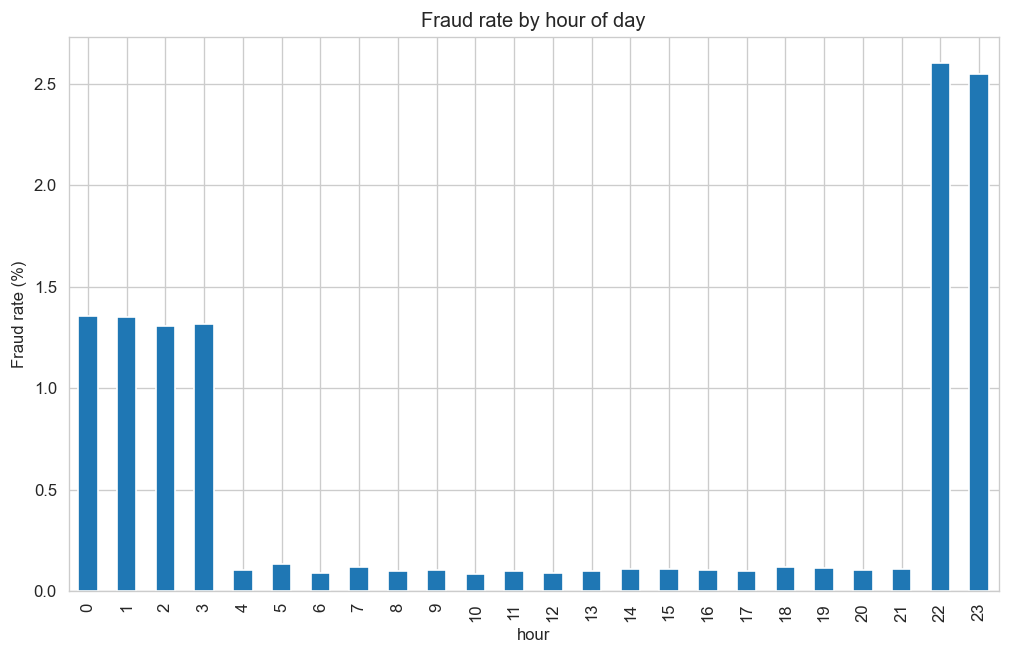

In [14]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.day_name()

fraud_by_hour = df.groupby('hour')['is_fraud'].mean() * 100
fig, ax = plt.subplots()
fraud_by_hour.plot(kind='bar', ax=ax)
ax.set_ylabel('Fraud rate (%)')
ax.set_title('Fraud rate by hour of day')
fig.savefig(f'{OUT_DIR}/fraud_rate_by_hour.png', bbox_inches='tight')

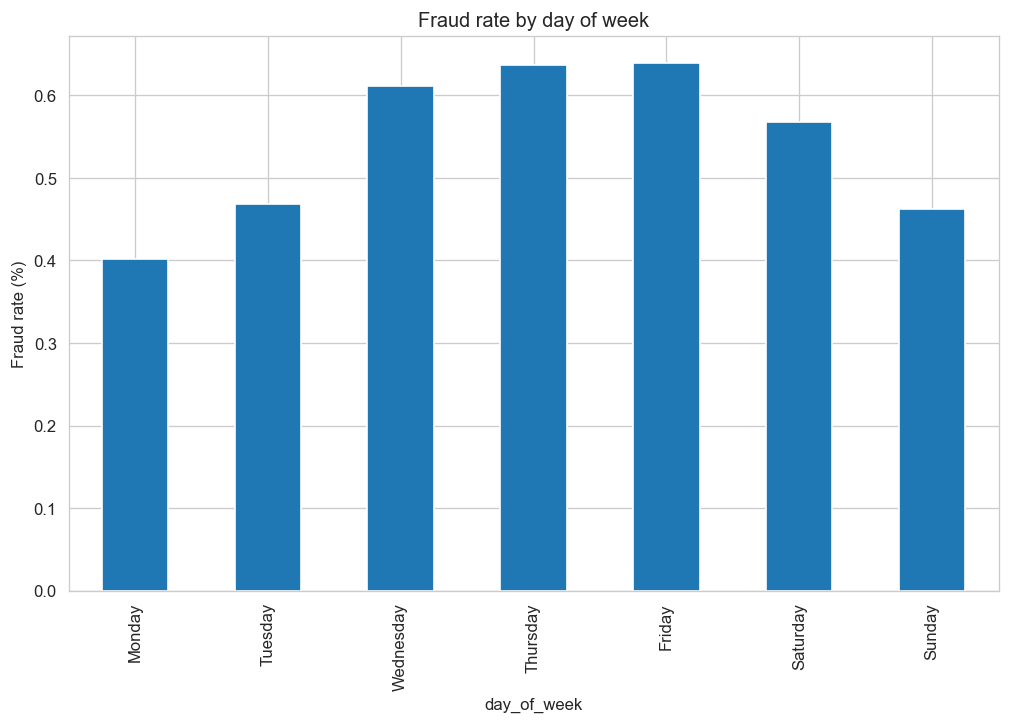

In [15]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fraud_by_day = df.groupby('day_of_week')['is_fraud'].mean().reindex(day_order) * 100
fig, ax = plt.subplots()
fraud_by_day.plot(kind='bar', ax=ax)
ax.set_ylabel('Fraud rate (%)')
ax.set_title('Fraud rate by day of week')
fig.savefig(f'{OUT_DIR}/fraud_rate_by_day.png', bbox_inches='tight')

## Age and geography

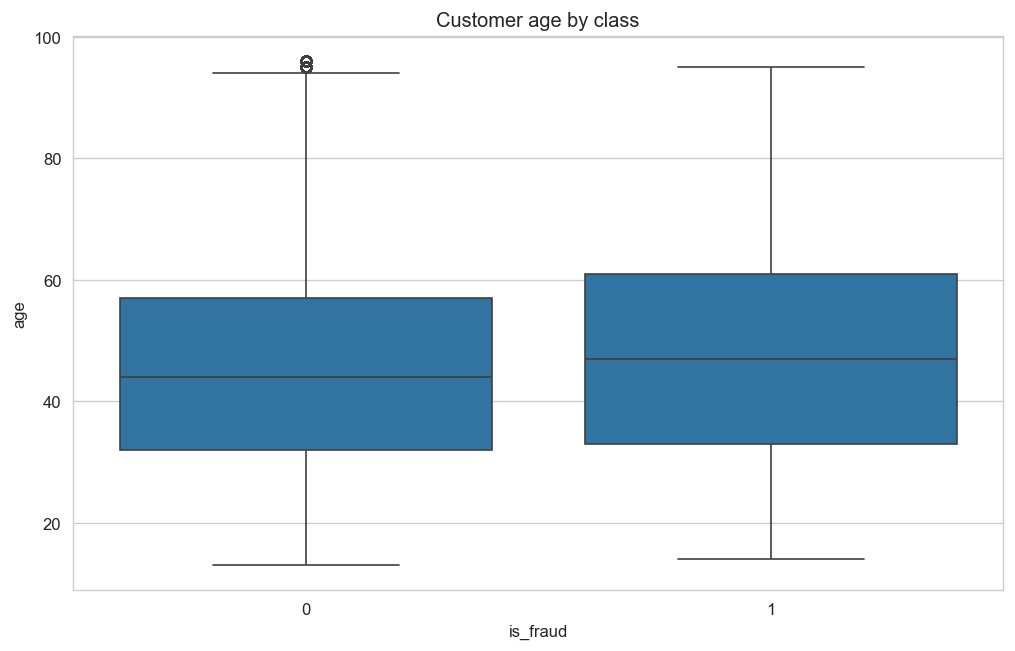

In [16]:
# age from dob, just a sanity check, not committing to using this feature yet
df['dob'] = pd.to_datetime(df['dob'])
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365
fig, ax = plt.subplots()
sns.boxplot(x='is_fraud', y='age', data=df, ax=ax)
ax.set_title('Customer age by class')
fig.savefig(f'{OUT_DIR}/age_by_class.png', bbox_inches='tight')

Distinct states: 51


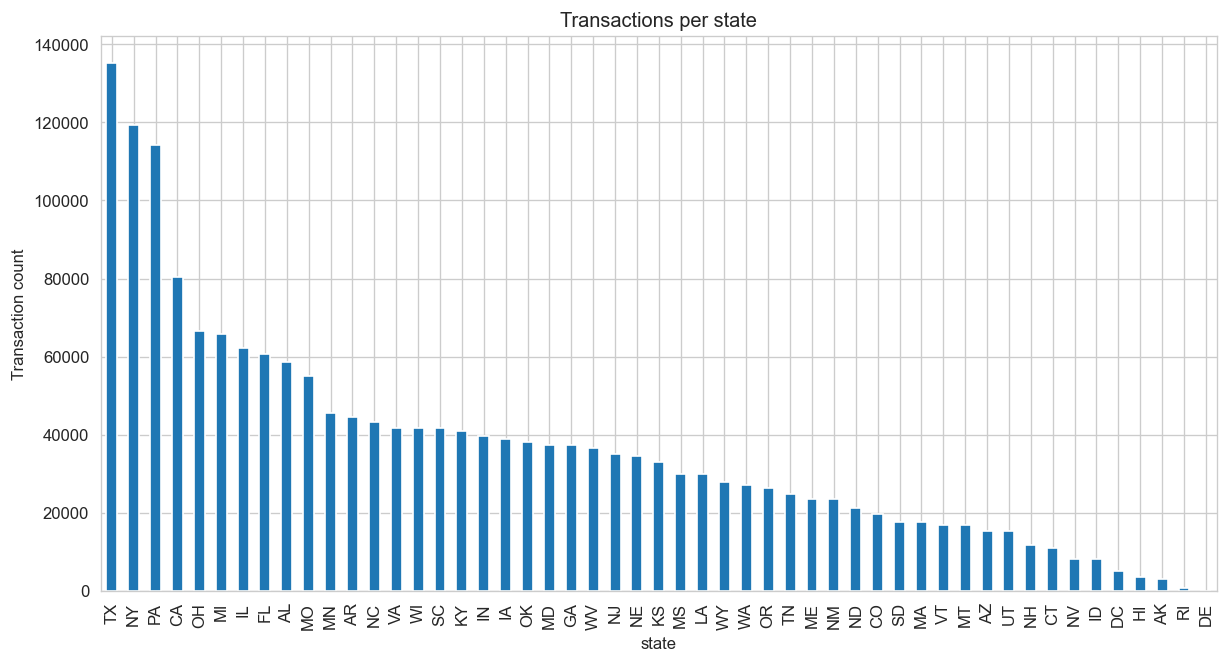

In [17]:
# geographic spread, just a distribution check, no mapping
print("Distinct states:", df['state'].nunique())
txns_by_state = df['state'].value_counts()
fig, ax = plt.subplots(figsize=(12, 6))
txns_by_state.plot(kind='bar', ax=ax)
ax.set_ylabel('Transaction count')
ax.set_title('Transactions per state')
fig.savefig(f'{OUT_DIR}/transactions_by_state.png', bbox_inches='tight')

## Summary

In [18]:
print(f"Combined rows: {df.shape[0]}, Cols: {df.shape[1]}")
print(f"Fraud rate: {fraud_pct[1]:.3f}%")
print(f"Missing cells: {df.isna().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"amt skew: {df['amt'].skew():.2f}")
print(f"Highest fraud-rate category: {fraud_by_category.index[0]} ({fraud_by_category.iloc[0]:.2f}%)")
print(f"Distinct categories: {df['category'].nunique()}, merchants: {df['merchant'].nunique()}, states: {df['state'].nunique()}")

Combined rows: 1852394, Cols: 25
Fraud rate: 0.521%


Missing cells: 0


Duplicate rows: 0
amt skew: 40.81
Highest fraud-rate category: shopping_net (1.59%)


Distinct categories: 14, merchants: 693, states: 51
